# Relative binding free energies demo: Tyk2

We want to know: Does ligand B bind TYK2 more tightly than ligand A? 

Rather than compute the absolute binding free energy of each ligand separately (hard,
slow, and the errors are large), we compute the *difference* directly via a relative 
binding free energy (RBFE) calculation. It is cheaper and more accurate because a lot 
of the error cancels out between two similar ligands.

The quantity we're after is:

$$\Delta\Delta G_{\text{bind}} = \Delta G_{\text{bind}}(B) - \Delta G_{\text{bind}}(A)$$

We get this from the thermodynamic cycle: rather than simulate the physical 
binding of A and B to the protein directly (slow to converge and hard to do 
well), we *alchemically* morph ligand A into ligand B, with the protein 
present (the complex leg) and without (the solvent leg). 

Because free energy is a state function, the cycle closes:

$$\Delta\Delta G_{\text{bind}} = \Delta G_{\text{complex}} - \Delta G_{\text{solvent}}$$



![Thermodynamic cycle for relative binding free energy](thermodynamic_cycle.png)



Neither of the two legs is a real, physically observable process (you'll
never see a TYK2 inhibitor spontaneously turn into a different molecule). That's
fine. The alchemical path just needs to connect the same two physical
end-states (A and B).

![alchemical_transformation](alchemical_transformation.png)


Before we can calculate $\Delta\Delta G$, we need to decide:
1. Which ligands to simulate, and what network architecture to use (Stage 1)
2. How to build a hybrid molecule that can smoothly interpolate between A
   and B (Stage 2)
3. How to run the simulation that samples along that alchemical path (Stage 3)
4. How to turn the resulting trajectories into a free energy estimate (Stage 4)


## Stage 0 - Environment setup and notebook imports

Create the demo environment using conda or mamba. Run these commands in your terminal:

```bash
mamba create -n rbfe-demo -c conda-forge python=3.10 \
    openff-toolkit rdkit lomap2 networkx py3dmol "setuptools<82" \
    alchemlyb pandas numpy matplotlib ipykernel
```

Then install gromacs (installing it separately simplifies the solve):

```bash
mamba activate rbfe-demo
mamba install -c conda-forge gromacs
```

Finally, install pmx from source:

```bash
git clone https://github.com/deGrootLab/pmx.git
cd pmx
git checkout develop
pip install --no-build-isolation .
```

Alternatively, you can use the provided `environment.yml` as a starting point (pmx still has to be installed separately):

```bash
mamba env create -f environment.yml
mamba activate rbfe-demo

git clone https://github.com/deGrootLab/pmx.git
cd pmx
git checkout develop
pip install --no-build-isolation .
```

If your environment is not available in the kernel selector, register it:

```bash
python -m ipykernel install --user --name rbfe-demo
```

Then quit or restart the application (e.g. VS Code) and you should be good to go.

In [1]:
import os
import subprocess
import itertools
from pathlib import Path
import subprocess
from joblib import Parallel, delayed
import shutil

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import Image, display
import ipywidgets as widgets
from rdkit import Chem
from rdkit.Chem import rdFMCS
import py3Dmol

import lomap
from openff.toolkit import Molecule, ForceField, Topology
from openff.units import unit
import pmx

import alchemlyb
from alchemlyb.parsing.gmx import extract_dHdl, extract_u_nk
from alchemlyb.estimators import TI, BAR, MBAR
from alchemlyb.preprocessing.subsampling import decorrelate_dhdl, decorrelate_u_nk
from alchemlyb.postprocessors.units import to_kcalmol
from alchemlyb.visualisation import plot_mbar_overlap_matrix, plot_ti_dhdl, plot_dF_state


PROJECT_ROOT = Path(".").resolve()
INPUTS_DIR = PROJECT_ROOT / "inputs"

sdf_path = INPUTS_DIR / "ligands.sdf"
PROTEIN_PDB = INPUTS_DIR / "protein.pdb"
WATER_ATOMTYPES_ITP = INPUTS_DIR / "itps" / "tip3p_atomtypes.itp"
WATER_MOLECULETYPE_ITP = INPUTS_DIR / "itps" / "tip3p.itp"
IONS_ATOMTYPES_ITP = INPUTS_DIR / "itps" / "ions_atomtypes.itp"
IONS_MOLECULETYPE_ITP = INPUTS_DIR / "itps" / "ions.itp"

em_mdp = INPUTS_DIR / "MDPS" / "em.mdp"
nvt_mdp = INPUTS_DIR / "MDPS" / "nvt.mdp"
npt_mdp = INPUTS_DIR / "MDPS" / "npt.mdp"
expanded_mdp = INPUTS_DIR / "MDPS" / "expanded.mdp"
fixed_mdp = INPUTS_DIR / "MDPS" / "fixed.mdp"
ions_mdp = INPUTS_DIR / "MDPS" / "ions.mdp"

INPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Inputs dir:", INPUTS_DIR)

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



Project root: /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output
Inputs dir: /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/inputs


## Stage 1 - Which ligands, and what network architecture?

We have 16 TYK2 ligands from the [OpenFE benchmark set](https://github.com/OpenFreeEnergy/openfe-benchmarks). Our goal is to rank how tightly each one binds relative to the others, which means computing a $\Delta\Delta G$ for pairs of ligands.

The question is which pairs. 

We could compute every pairwise $\Delta\Delta G$'s, but that is 16 choose 2 = 120 separate transformations, and most of those pairs may be structurally distant from each other.  A transformation between two very dissimilar ligands may converge slowly, carry large uncertainty, and waste compute.

Instead we impose a network architecture. We can pick one ligand as a **hub** and connect every other ligand directly to it, forming a **star network**. Every edge is then a transformation from the hub to one other ligand (hub, ligand_i), so we compute only 15 transformations rather than 120. If we choose the hub well, each of those 15 edges involves a comparatively modest, well-behaved structural change, which is the regime where these calculations are most reliable.

The tradeoff of a star is that it has no redundancy: every ligand's free energy is tied to the hub through a single path, so there is no independent route to cross-check any one edge. More elaborate networks add extra edges to form cycles, which lets you check consistency (a cycle should sum to zero), at the cost of running more transformations. For this demo the star keeps both the compute and the bookkeeping simple.

In [2]:
# Load all ligands from the multi-molecule SDF (TYK2 benchmark set).
# removeHs=False keeps explicit hydrogens, since we want them for the
# hybrid topology / atom mapping steps later.
suppl = Chem.SDMolSupplier(str(sdf_path), removeHs=False)
ligands = {mol.GetProp("_Name"): mol for mol in suppl if mol is not None}
print(f"Loaded {len(ligands)} ligands: {list(ligands)}")


Loaded 16 ligands: ['jmc_23', 'ejm_47', 'ejm_49', 'ejm_31', 'ejm_45', 'ejm_44', 'ejm_43', 'ejm_50', 'ejm_42', 'ejm_55', 'ejm_48', 'ejm_54', 'jmc_28', 'jmc_27', 'jmc_30', 'ejm_46']


### Visualize the ligands

Before we build the network, it helps to look at the ligands themselves. They share a common scaffold and differ mainly in their substituents, which is what makes this set a good candidate for relative free energy calculations in the first place.

As you scroll through them, consider: which ligand would you expect to end up as the hub? A good hub sits structurally "in the middle" of the set, close to as many of the others as possible, so that no single edge has to span a large or awkward change.

In [3]:
def show_ligand_browser(mols_dict, width=500, height=400):
    """Display an interactive py3Dmol viewer with a dropdown to browse
    through a dict of {name: RDKit Mol}.
    """
    names = list(mols_dict.keys())
    dropdown = widgets.Dropdown(options=names, description="Ligand:")
    out = widgets.Output()

    def render(name):
        with out:
            out.clear_output(wait=True)
            view = py3Dmol.view(width=width, height=height)
            view.addModel(Chem.MolToMolBlock(mols_dict[name]), "mol")
            view.setStyle({"stick": {}})
            view.zoomTo()
            view.show()

    dropdown.observe(lambda change: render(change["new"]), names="value")
    display(dropdown, out)
    render(names[0])

show_ligand_browser(ligands)

Dropdown(description='Ligand:', options=('jmc_23', 'ejm_47', 'ejm_49', 'ejm_31', 'ejm_45', 'ejm_44', 'ejm_43',…

Output()

### Compute LOMAP scores and determine hub

To choose the hub objectively, we need a way to measure how structurally similar two ligands are. We use [LOMAP](https://github.com/OpenFreeEnergy/Lomap), which scores each pair based largely on the size of their maximum common substructure (the shared atoms a transformation would keep fixed), with penalties applied for changes known to be difficult to sample well, such as breaking or forming rings. A higher LOMAP score means an easier, more reliable transformation.

We compute this score for every pair, giving a similarity matrix over all 16 ligands. The hub should be the most central ligand: the one that is, on average, most similar to all the others. We find it by taking each ligand's mean similarity across the matrix and selecting the ligand with the highest value. That ligand is close to the most other ligands, so building a star around it minimizes the difficulty of the individual edges.

In [4]:
# LOMAP's DBMolecules wants a directory of individual per-ligand SDFs,
# not a single multi-mol file, so split them out here.
lig_dir = INPUTS_DIR / "individual"
lig_dir.mkdir(exist_ok=True)
for name, mol in ligands.items():
    w = Chem.SDWriter(str(lig_dir / f"{name}.sdf"))
    w.write(mol)
    w.close()

# Compute pairwise LOMAP similarity scores for every ligand pair.
db = lomap.DBMolecules(str(lig_dir), output=False)
strict_mtx, loose_mtx = db.build_matrices()
similarity_matrix = strict_mtx.to_numpy_2D_array()
names = [m.getName().replace(".sdf", "") for m in db]

sim_df = pd.DataFrame(similarity_matrix, index=names, columns=names)

# Hub = the ligand with the highest average similarity to all others 
# i.e. the most "central" scaffold, best suited as the star network's core.
mean_sim = sim_df.mean(axis=1).sort_values(ascending=False)
hub = mean_sim.index[0]
print("Candidate hub ligand:", hub)
print(mean_sim)

Candidate hub ligand: ejm_31
ejm_31    0.520240
ejm_42    0.505548
ejm_50    0.494771
ejm_55    0.493515
ejm_43    0.473071
ejm_54    0.451670
ejm_44    0.433434
ejm_46    0.386402
jmc_28    0.373949
jmc_23    0.371575
jmc_27    0.371575
jmc_30    0.328009
ejm_45    0.292768
ejm_47    0.161079
ejm_48    0.145992
ejm_49    0.132297
dtype: float64


### Build the star network

With the hub chosen, we connect every other ligand directly to it. Each connection is an **edge**, and each edge is one alchemical transformation we will compute (hub to spoke). For 16 ligands this gives 15 edges, one per spoke.

Hub: ejm_31
15 spokes: ['ejm_42', 'ejm_50', 'ejm_55', 'ejm_43', 'ejm_54', 'ejm_44', 'ejm_45', 'ejm_46', 'ejm_47', 'jmc_23', 'jmc_27', 'jmc_28', 'ejm_48', 'jmc_30', 'ejm_49']

15 edges in the star network:
  ejm_31 -- ejm_42  (LOMAP score = 0.90)
  ejm_31 -- ejm_50  (LOMAP score = 0.90)
  ejm_31 -- ejm_55  (LOMAP score = 0.86)
  ejm_31 -- ejm_43  (LOMAP score = 0.82)
  ejm_31 -- ejm_54  (LOMAP score = 0.78)
  ejm_31 -- ejm_44  (LOMAP score = 0.74)
  ejm_31 -- ejm_45  (LOMAP score = 0.74)
  ejm_31 -- ejm_46  (LOMAP score = 0.37)
  ejm_31 -- ejm_47  (LOMAP score = 0.33)
  ejm_31 -- jmc_23  (LOMAP score = 0.33)
  ejm_31 -- jmc_27  (LOMAP score = 0.33)
  ejm_31 -- jmc_28  (LOMAP score = 0.33)
  ejm_31 -- ejm_48  (LOMAP score = 0.30)
  ejm_31 -- jmc_30  (LOMAP score = 0.30)
  ejm_31 -- ejm_49  (LOMAP score = 0.27)


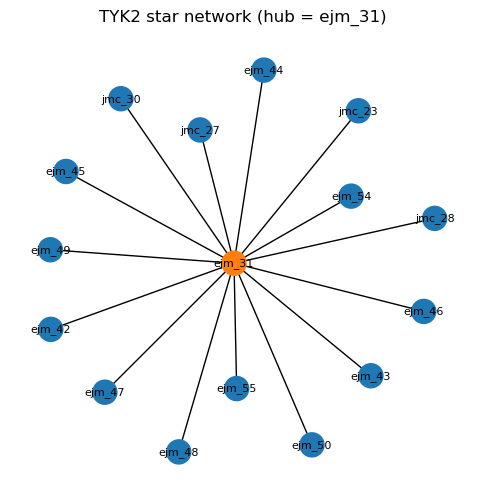

In [5]:
# Every non-hub ligand becomes a spoke in the star network, connected directly to the hub.
spokes = list(sim_df.loc[hub].drop(hub).sort_values(ascending=False).index)
print(f"Hub: {hub}")
print(f"{len(spokes)} spokes: {spokes}")

# Build the star network as a NetworkX graph: hub connected directly to
# every spoke, each edge annotated with its LOMAP score for later reference.
G = nx.Graph()
G.add_node(hub, is_hub=True)
for spoke in spokes:
    G.add_node(spoke, is_hub=False)
    G.add_edge(hub, spoke, lomap_score=sim_df.loc[hub, spoke])

edges = list(G.edges(data=True))
print(f"\n{len(edges)} edges in the star network:")
for a, b, d in edges:
    print(f"  {a} -- {b}  (LOMAP score = {d['lomap_score']:.2f})")

# Visualize the network: hub in orange, spokes in blue.
fig, ax = plt.subplots(figsize=(6, 6))
pos = nx.spring_layout(G, seed=1)
node_colors = ["tab:orange" if G.nodes[n].get("is_hub") else "tab:blue" for n in G.nodes]
nx.draw(G, pos, with_labels=True, node_color=node_colors, ax=ax, font_size=8)
ax.set_title(f"TYK2 star network (hub = {hub})")
plt.show()

### Visualize the edges

A LOMAP score is a single number; it tells us an edge should be tractable, but not what is actually changing between the two ligands. Since the difficulty of a transformation depends on which atoms are being added, removed, or modified, it is worth looking at the edges directly before committing compute to them.

For any edge in the star network, we compute the maximum common substructure (MCS) between the hub and the spoke and highlight everything that is *not* in the MCS: the atoms that are actually being perturbed in that transformation. The MCS is also the set of atoms that will be held in common when we build the hybrid topology in Stage 2, so this view is a preview of what that transformation will have to do.

If an edge's LOMAP score looks fine but the highlighted region is a large or awkward change (for example a ring opening rather than a small substituent swap), that is worth flagging now, before spending simulation time on an edge that may converge poorly.

In [6]:
def compute_mcs(mol_a, mol_b):
    """Find the maximum common substructure (MCS) between two ligands and
    return each molecule's matched atom indices plus the raw MCS result.
    """
    mcs_result = rdFMCS.FindMCS(
        [mol_a, mol_b],
        atomCompare=rdFMCS.AtomCompare.CompareElements,
        bondCompare=rdFMCS.BondCompare.CompareOrder,
        ringMatchesRingOnly=True,
        completeRingsOnly=True,
        timeout=30,
    )
    mcs_query = Chem.MolFromSmarts(mcs_result.smartsString)
    match_a = mol_a.GetSubstructMatch(mcs_query)
    match_b = mol_b.GetSubstructMatch(mcs_query)
    return match_a, match_b, mcs_result


def draw_2d_highlighted(mol, match, size=(350, 350)):
    """Render a 2D depiction of `mol` with every atom NOT in `match`
    (i.e. not part of the MCS) highlighted in red (i.e. visually flag the
    region of the molecule being added/removed/modified in this edge's
    alchemical transformation).
    """
    mol2d = Chem.Mol(mol)
    Chem.rdDepictor.Compute2DCoords(mol2d)

    non_mcs_atoms = [i for i in range(mol2d.GetNumAtoms()) if i not in match]
    non_mcs_bonds = [
        b.GetIdx() for b in mol2d.GetBonds()
        if b.GetBeginAtomIdx() in non_mcs_atoms or b.GetEndAtomIdx() in non_mcs_atoms
    ]

    drawer = rdMolDraw2D.MolDraw2DCairo(*size)
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol2d,
        highlightAtoms=non_mcs_atoms,
        highlightBonds=non_mcs_bonds,
        highlightAtomColors={i: (1.0, 0.4, 0.4) for i in non_mcs_atoms},
        highlightBondColors={i: (1.0, 0.4, 0.4) for i in non_mcs_bonds},
    )
    drawer.FinishDrawing()
    return drawer.GetDrawingText()


def show_edge_mcs_2d(hub_name, spoke_name):
    """Display hub and spoke ligands side by side, each with their
    non-MCS (perturbed) atoms highlighted, plus the MCS size and LOMAP
    score for that edge.
    """
    hub_mol, spoke_mol = ligands[hub_name], ligands[spoke_name]
    hub_match, spoke_match, mcs_result = compute_mcs(hub_mol, spoke_mol)

    hub_png = draw_2d_highlighted(hub_mol, hub_match)
    spoke_png = draw_2d_highlighted(spoke_mol, spoke_match)

    hbox = widgets.HBox([
        widgets.VBox([widgets.Label(f"{hub_name} (hub)"), widgets.Image(value=hub_png, format="png")]),
        widgets.VBox([widgets.Label(f"{spoke_name} (spoke)"), widgets.Image(value=spoke_png, format="png")]),
    ])

    n_mcs = mcs_result.numAtoms
    info_text = (
        f"MCS = {n_mcs} atoms ({n_mcs / hub_mol.GetNumAtoms():.0%} of hub, "
        f"{n_mcs / spoke_mol.GetNumAtoms():.0%} of spoke) | "
        f"LOMAP score = {sim_df.loc[hub_name, spoke_name]:.2f}"
    )
    info_label = widgets.Label(info_text)

    display(widgets.VBox([hbox, info_label]))


# dropdown to browse every edge in the star network
edge_labels = [f"{a} -- {b}" for a, b, _ in edges]
edge_lookup = {f"{a} -- {b}": (a, b) for a, b, _ in edges}

edge_dropdown = widgets.Dropdown(options=edge_labels, description="Edge:")
out = widgets.Output()

def render_edge(label):
    with out:
        out.clear_output(wait=True)
        a, b = edge_lookup[label]
        show_edge_mcs_2d(a, b)

edge_dropdown.observe(lambda change: render_edge(change["new"]), names="value")
display(edge_dropdown, out)
render_edge(edge_labels[0])

Dropdown(description='Edge:', options=('ejm_31 -- ejm_42', 'ejm_31 -- ejm_50', 'ejm_31 -- ejm_55', 'ejm_31 -- …

Output()

## Stage 2 - Building a molecule that can be two things at once

The core trick of a relative free energy calculation is to treat the change from ligand A to ligand B not as a physical event, but as a continuous mathematical interpolation. We introduce a coupling parameter, λ, that runs from 0 to 1: at λ = 0 the system is ligand A, at λ = 1 it is ligand B, and at intermediate values it is a blend of the two. To make that interpolation possible, GROMACS needs a single topology that describes *both* ligands at once, called a **hybrid topology**.

The hybrid topology works by sorting every atom into one of two categories. Atoms that exist in both A and B, the shared core identified by the atom mapping, are present the entire time and simply carry both their A-state and B-state parameters. Atoms that exist in only one of the two ligands become **dummy atoms** in the state where they do not belong: they keep their bonded geometry but have their nonbonded interactions scaled away, so they smoothly vanish or appear as λ moves across its range. This is why the quality of the shared core matters so much; the more atoms A and B genuinely have in common, the fewer atoms have to be created or destroyed, and the smoother and better-converged the transformation.

We build this in two stages:

1. **Parameterize each ligand** with OpenFF (Sage), and the protein with its own SMIRNOFF-ported force field. This assigns the actual force field parameters (charges, bonded terms, van der Waals terms) to every atom.
2. **Map and merge** the ligand pairs with `pmx`: first find an atom mapping, which is the correspondence between atoms in A and atoms in B based on their maximum common substructure, then build the dual-topology hybrid molecule from that mapping.

Once we have a hybrid ligand, we build two separate simulation systems from it: the ligand alone in water (the **solvent leg**) and the ligand bound to the protein in water (the **complex leg**). Both legs run the same A-to-B transformation; taking the difference between them is what isolates the *binding* contribution, since everything common to the ligand in isolation cancels out.

### Stage 2a - Parameterize the protein and ligands with OpenFF

Before we can build a hybrid, each molecule needs a force field: a full set of parameters describing how its atoms bond, bend, twist, and interact. We use OpenFF's Sage force field for the small-molecule ligands and a SMIRNOFF-ported version of the Amber ff14SB force field for the protein.

Note: Partial charges are assigned with AM1-BCC due to pmx's incompatibility with more recent OpenFF toolkit versions where Nagl charges are implemented. 

In [7]:
# Openff Sage 2.2.1 force field used for all ligand parameterization

FORCEFIELD = "openff-2.2.1.offxml"

ligand_dir = INPUTS_DIR / "ligand_params"
ligand_dir.mkdir(exist_ok=True)


def parameterize_ligand(name: str, rdmol, forcefield_name: str, out_root: Path):
    """Parameterize a single ligand with OpenFF and write GROMACS .gro/.top.
    Designed to run inside a joblib worker process.
    """
    from openff.toolkit import Molecule, ForceField
    from openff.units import unit

    ff = ForceField(forcefield_name)

    off_mol = Molecule.from_rdkit(rdmol, allow_undefined_stereo=True)
    off_mol.assign_partial_charges(partial_charge_method="am1bcc")
    off_mol.name = name

    topology = off_mol.to_topology()
    topology.box_vectors = unit.Quantity([3, 3, 3], unit.nanometer)

    interchange = ff.create_interchange(topology)

    out_dir = out_root / name
    out_dir.mkdir(exist_ok=True)
    interchange.to_gro(str(out_dir / f"{name}.gro"))
    interchange.to_top(str(out_dir / f"{name}.top"))
    return name, off_mol


# Parameterize all ligands concurrently (n_jobs=-1 uses all available cores).
results = Parallel(n_jobs=-4, verbose=10)(
    delayed(parameterize_ligand)(name, ligands[name], FORCEFIELD, ligand_dir)
    for name in ligands
)

off_molecules = dict(results)
for name in off_molecules:
    print(f"Parameterized {name} -> {ligand_dir / name}")

[Parallel(n_jobs=-4)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=-4)]: Done   3 out of  16 | elapsed:  1.3min remaining:  5.8min
[Parallel(n_jobs=-4)]: Done   5 out of  16 | elapsed:  1.5min remaining:  3.3min
[Parallel(n_jobs=-4)]: Done   7 out of  16 | elapsed:  1.7min remaining:  2.2min
[Parallel(n_jobs=-4)]: Done   9 out of  16 | elapsed:  1.9min remaining:  1.5min
[Parallel(n_jobs=-4)]: Done  11 out of  16 | elapsed:  2.3min remaining:  1.1min
[Parallel(n_jobs=-4)]: Done  13 out of  16 | elapsed:  2.5min remaining:   34.1s


Parameterized jmc_23 -> /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/inputs/ligand_params/jmc_23
Parameterized ejm_47 -> /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/inputs/ligand_params/ejm_47
Parameterized ejm_49 -> /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/inputs/ligand_params/ejm_49
Parameterized ejm_31 -> /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/inputs/ligand_params/ejm_31
Parameterized ejm_45 -> /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/inputs/ligand_params/ejm_45
Parameterized ejm_44 -> /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/inputs/ligand_params/ejm_44
Parameterized ejm_43 -> /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/inputs/ligand_params/ejm_43
Parameterized ejm_50 -> /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/inputs/ligand_params/ejm_50
Parameterized ejm_42 -> /Users/lwhitm1/projects/free_ene

[Parallel(n_jobs=-4)]: Done  16 out of  16 | elapsed:  2.8min finished


In [8]:
# ff14sb ported to SMIRNOFF format, with OpenFF-style improper torsions 
# used for protein parameterization.
ff14sb = ForceField("ff14sb_off_impropers_0.0.4.offxml")
protein_topology = Topology.from_pdb(str(PROTEIN_PDB))

for molecule in protein_topology.molecules:
    molecule.name = "PROT"

protein_topology.box_vectors = unit.Quantity([6, 6, 6], unit.nanometer)
protein_ic = ff14sb.create_interchange(protein_topology)

protein_dir = INPUTS_DIR / "protein_params"
protein_dir.mkdir(exist_ok=True)
protein_ic.to_gro(str(protein_dir / "protein.gro"))
protein_ic.to_top(str(protein_dir / "protein.top"))
print(f"Parameterized protein -> {protein_dir}")

Parameterized protein -> /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/inputs/protein_params


### Stage 2b - Hybrid topology generation with pmx

With every ligand parameterized, we now build the hybrid molecule for each edge. This is the job of `pmx`, and it happens in two steps per edge.

First, **atom mapping**: `pmx` determines which atom in the hub corresponds to which atom in the spoke, based on their maximum common substructure. This mapping defines the shared core (atoms that will be present in both states) and, by exclusion, the atoms that must appear or disappear across the transformation.

Second, **hybrid construction**: from that mapping, `pmx` writes a dual-topology molecule in which the shared atoms carry parameters for both end states and the unique atoms are set up as dummies in the state where they are absent. The output is a set of files describing this hybrid molecule, which the next stage assembles into a full simulation system.


In [9]:
def run_gmx(*args, cwd):
    """Run a gmx subcommand, raising with the captured stderr on failure."""
    cmd = ["gmx"] + list(args)
    result = subprocess.run(cmd, cwd=cwd, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(f"gmx {args[0]} failed:\n{result.stderr}")


def run_pmx(subcmd, *args, cwd=None):
    """Run a pmx CLI subcommand (atomMapping, ligandHybrid, etc.), raising
    with captured stderr on failure.
    """
    cmd = ["pmx", subcmd] + list(args)
    result = subprocess.run(cmd, cwd=cwd, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(f"pmx {subcmd} failed:\n{result.stderr}")
    return result


def build_hybrid_edge(hub_name, spoke_name, hybrid_dir: Path, ligand_dir: Path):
    """Build a pmx hybrid topology/structure for one hub-spoke edge:
    1. Convert each ligand's .gro to .pdb (pmx's CLI tools require .pdb input,
       and pmx's PDB parser needs GROMACS-style atom names/elements that
       editconf produces but interchange.to_pdb() does not).
    2. Run pmx atomMapping to get an MCS-based atom correspondence between
       the two ligands.
    3. Run pmx ligandHybrid to build the dual-topology hybrid structure
       (mergedA.pdb/mergedB.pdb) and topology (merged.itp/ffmerged.itp).

    Designed to run inside a joblib worker process.

    Returns:
        (edge, edge_dir, error_or_None) where edge = (hub_name, spoke_name)
    """
    edge_dir = hybrid_dir / f"{hub_name}_{spoke_name}"
    edge_dir.mkdir(exist_ok=True)

    try:
        struct_A_pdb = edge_dir / f"{hub_name}.pdb"
        struct_B_pdb = edge_dir / f"{spoke_name}.pdb"
        run_gmx("editconf", "-f", str(ligand_dir / hub_name / f"{hub_name}.gro"),
                "-o", str(struct_A_pdb), cwd=edge_dir)
        run_gmx("editconf", "-f", str(ligand_dir / spoke_name / f"{spoke_name}.gro"),
                "-o", str(struct_B_pdb), cwd=edge_dir)

        top_A = ligand_dir / hub_name / f"{hub_name}.top"
        top_B = ligand_dir / spoke_name / f"{spoke_name}.top"

        pairs1 = edge_dir / "pairs1.dat"
        run_pmx("atomMapping",
                "-i1", str(struct_A_pdb), "-i2", str(struct_B_pdb),
                "-o1", str(pairs1), "-o2", str(edge_dir / "pairs2.dat"),
                "-score", str(edge_dir / "score.dat"),
                "-log", str(edge_dir / "mapping.log"),
                cwd=edge_dir)

        run_pmx("ligandHybrid",
                "-i1", str(struct_A_pdb), "-i2", str(struct_B_pdb),
                "-itp1", str(top_A), "-itp2", str(top_B),
                "-pairs", str(pairs1),
                "-oA", str(edge_dir / "mergedA.pdb"),
                "-oB", str(edge_dir / "mergedB.pdb"),
                "-oitp", str(edge_dir / "merged.itp"),
                "-offitp", str(edge_dir / "ffmerged.itp"),
                "-log", str(edge_dir / "hybrid.log"),
                cwd=edge_dir)

        return (hub_name, spoke_name), edge_dir, None
    except Exception as e:
        return (hub_name, spoke_name), edge_dir, str(e)


hybrid_dir = PROJECT_ROOT / "hybrids"
hybrid_dir.mkdir(exist_ok=True)

# Build hybrid topologies for every edge in the star network concurrently
results = Parallel(n_jobs=-4, verbose=10)(
    delayed(build_hybrid_edge)(hub_name, spoke_name, hybrid_dir, ligand_dir)
    for hub_name, spoke_name, edata in edges
)

# Collect results
hybrid_edges = {}
failed_edges = {}
for edge, edge_dir, error in results:
    if error is None:
        hybrid_edges[edge] = edge_dir
        print(f"{edge[0]} -> {edge[1]}: Success")
    else:
        failed_edges[edge] = error
        print(f"{edge[0]} -> {edge[1]}: {error}")

print(f"\n{len(hybrid_edges)}/{len(edges)} edges built successfully.")
if failed_edges:
    print("Failed edges:", list(failed_edges))

[Parallel(n_jobs=-4)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=-4)]: Done   2 out of  15 | elapsed:    6.6s remaining:   42.9s
[Parallel(n_jobs=-4)]: Done   4 out of  15 | elapsed:    6.6s remaining:   18.2s
[Parallel(n_jobs=-4)]: Done   6 out of  15 | elapsed:    6.7s remaining:   10.0s
[Parallel(n_jobs=-4)]: Done   8 out of  15 | elapsed:    6.7s remaining:    5.9s
[Parallel(n_jobs=-4)]: Done  10 out of  15 | elapsed:    6.8s remaining:    3.4s
[Parallel(n_jobs=-4)]: Done  12 out of  15 | elapsed:   10.0s remaining:    2.5s


ejm_31 -> ejm_42: Success
ejm_31 -> ejm_50: Success
ejm_31 -> ejm_55: Success
ejm_31 -> ejm_43: Success
ejm_31 -> ejm_54: Success
ejm_31 -> ejm_44: Success
ejm_31 -> ejm_45: Success
ejm_31 -> ejm_46: Success
ejm_31 -> ejm_47: Success
ejm_31 -> jmc_23: Success
ejm_31 -> jmc_27: Success
ejm_31 -> jmc_28: Success
ejm_31 -> ejm_48: Success
ejm_31 -> jmc_30: Success
ejm_31 -> ejm_49: Success

15/15 edges built successfully.


[Parallel(n_jobs=-4)]: Done  15 out of  15 | elapsed:   10.7s finished


#### Stage 2c: assembling simulation-ready systems from the hybrid topology

pmx writes the hybrid ligand's topology and structure as separate files (`merged.itp`, `ffmerged.itp`, `mergedA.pdb`), but these are only the ligand. An executable GROMACS system also needs the surrounding environment: a simulation box, water, counter-ions to neutralize any net charge, and, for the complex leg, the protein. The functions below assemble those pieces into complete, solvated, neutralized systems for each leg of the thermodynamic cycle.

There is one recurring complication that most of these helpers exist to handle. Because each molecule was parameterized independently, each of their topology files carries its own self-contained parameter definitions. GROMACS requires these to be combined in a specific order (all atom-type definitions before any molecule that uses them, and no duplicate or conflicting sections), so a good deal of the work here is reading, splicing, and reordering topology sections so the final file is valid.

The work falls into a few groups:

- **`.top` parsing** (`get_moleculetype_name`, `extract_atomtypes_block`, `extract_moleculetype_block`, `merge_atomtypes_blocks`): utilities for reading and recombining sections of OpenFF-generated topology files in an order GROMACS accepts.
- **Topology assembly** (`wrap_pmx_hybrid_top`, `build_complex_top`, `build_complex_raw`, `merge_gro`): write the actual `hybrid.top` (solvent leg) and `complex_raw.top` plus merged coordinates (complex leg).
- **System preparation** (`run_ions`, `find_sol_group_index`, `make_posre`, `add_posre_restraints`): neutralize net charge with counter-ions and generate position restraints for the equilibration stages.
- **`build_leg`**: the top-level driver that ties it all together for one leg, in the order assemble, box, solvate, neutralize.

`run_gmx` is the subprocess wrapper the GROMACS-calling helpers share.

In [10]:
def run_gmx(*args, cwd, env_overrides=None):
    """Run a gmx subcommand, raising with the captured stderr on failure.
    env_overrides: optional dict merged into the subprocess environment.
    """
    import os
    cmd = ["gmx"] + list(args)
    print("  $", " ".join(cmd))
    env = {**os.environ, **(env_overrides or {})}
    result = subprocess.run(cmd, cwd=cwd, capture_output=True, text=True, env=env)
    if result.returncode != 0:
        print(result.stderr)
        result.check_returncode()


def get_moleculetype_name(itp_path: Path) -> str:
    """Pull the molecule name out of a .itp/.top file's [ moleculetype ]
    section (the first non-comment token on the line following the header).
    """
    lines = itp_path.read_text().splitlines()
    for i, line in enumerate(lines):
        if line.strip().lower().startswith("[ moleculetype ]"):
            for follow in lines[i + 1:]:
                stripped = follow.strip()
                if stripped and not stripped.startswith(";"):
                    return stripped.split()[0]
    raise ValueError(f"Could not find [ moleculetype ] name in {itp_path}")


def extract_atomtypes_block(top_path: Path) -> str:
    """Return everything from the top of an OpenFF-generated .top file up
    to (not including) its first [ moleculetype ] section (i.e. the
    [ defaults ] and [ atomtypes ] blocks).
    """
    lines = top_path.read_text().splitlines(keepends=True)
    out = []
    for line in lines:
        if line.strip().lower().startswith("[ moleculetype ]"):
            break
        out.append(line)
    return "".join(out)


def merge_atomtypes_blocks(*top_paths: Path) -> str:
    """Combine the [ atomtypes ] rows from multiple OpenFF .top files into
    a single block, keeping only one [ defaults ] header (from the first
    file passed in).
    """
    defaults_header = []
    all_rows = []
    for i, path in enumerate(top_paths):
        block = extract_atomtypes_block(path)
        lines = block.splitlines(keepends=True)
        in_defaults, in_atomtypes = False, False
        for line in lines:
            stripped = line.strip().lower()
            if stripped.startswith("[ defaults ]"):
                in_defaults, in_atomtypes = True, False
                if i == 0:
                    defaults_header.append(line)
                continue
            if stripped.startswith("[ atomtypes ]"):
                in_defaults, in_atomtypes = False, True
                continue
            if in_defaults and i == 0:
                defaults_header.append(line)
            elif in_atomtypes:
                all_rows.append(line)
    return "".join(defaults_header) + "[ atomtypes ]\n" + "".join(all_rows)


def extract_moleculetype_block(top_path: Path) -> str:
    """Return everything from a .top file's [ moleculetype ] section up to
    (not including) its [ system ] section (i.e. the full moleculetype
    definition (atoms, bonds, angles, etc.)).
    """
    lines = top_path.read_text().splitlines(keepends=True)
    out, capturing = [], False
    for line in lines:
        if line.strip().lower().startswith("[ moleculetype ]"):
            capturing = True
        if line.strip().lower().startswith("[ system ]"):
            break
        if capturing:
            out.append(line)
    return "".join(out)


def merge_gro(protein_gro: Path, ligand_gro: Path, out_gro: Path):
    """Concatenate atom records from a protein .gro and a ligand .gro into
    a single combined complex .gro (protein atoms first, then ligand atoms).
    Box vectors are copied from the protein file as a placeholder.
    """
    def read_atoms(path):
        lines = path.read_text().splitlines()
        n_atoms = int(lines[1].strip())
        return lines[2:2 + n_atoms], lines[-1]  # atom lines, box line

    prot_atoms, box_line = read_atoms(protein_gro)
    lig_atoms, _ = read_atoms(ligand_gro)

    total = len(prot_atoms) + len(lig_atoms)
    out_lines = ["Complex: protein + hybrid ligand", str(total)]
    out_lines += prot_atoms + lig_atoms
    out_lines.append(box_line)
    out_gro.write_text("\n".join(out_lines) + "\n")


def wrap_pmx_hybrid_top(edge_dir: Path, hub_name: str, spoke_name: str) -> Path:
    """Build a standalone hybrid.top for the solvent leg: pmx's merged.itp
    (dual-topology hybrid ligand) and ffmerged.itp (dummy-atom types) need
    to be wrapped with real atomtypes (pulled from both the hub's and
    spoke's OpenFF .top, plus water/ion moleculetypes, in an order that satisfies
    GROMACS's requirements.
    """
    merged_itp = edge_dir / "merged.itp"
    molname = get_moleculetype_name(merged_itp)

    hub_top = ligand_dir / hub_name / f"{hub_name}.top"
    spoke_top = ligand_dir / spoke_name / f"{spoke_name}.top"

    atomtypes_itp = edge_dir / "base_atomtypes.itp"
    atomtypes_itp.write_text(merge_atomtypes_blocks(hub_top, spoke_top))

    hybrid_top = edge_dir / "hybrid.top"
    hybrid_top.write_text(f"""\
#include "{atomtypes_itp.name}"
#include "{(edge_dir / 'ffmerged.itp').name}"
#include "{WATER_ATOMTYPES_ITP}"
#include "{IONS_ATOMTYPES_ITP}"
#include "{merged_itp.name}"
#include "{WATER_MOLECULETYPE_ITP}"
#include "{IONS_MOLECULETYPE_ITP}"

[ system ]
Hybrid ligand {molname}

[ molecules ]
{molname}    1
""")
    return hybrid_top


def build_complex_top(edge_dir: Path, hub_name: str, spoke_name: str) -> Path:
    """Build a standalone complex_raw.top for the complex leg: same
    atomtypes-then-moleculetypes structure as wrap_pmx_hybrid_top, but also
    folding in the protein's atomtypes/moleculetype and, if POSRES is
    defined at grompp time, position restraint includes for both the
    protein and the hybrid ligand (generated via add_posre_restraints).
    """
    protein_top = protein_dir / "protein.top"
    protein_moltype = extract_moleculetype_block(protein_top)
    protein_molname = get_moleculetype_name(protein_top)

    hub_top = ligand_dir / hub_name / f"{hub_name}.top"
    spoke_top = ligand_dir / spoke_name / f"{spoke_name}.top"
    lig_molname = get_moleculetype_name(edge_dir / "merged.itp")

    combined_atomtypes = edge_dir / "complex_atomtypes.itp"
    combined_atomtypes.write_text(merge_atomtypes_blocks(protein_top, hub_top, spoke_top))

    protein_moltype_itp = edge_dir / "protein_moleculetype.itp"
    protein_moltype_itp.write_text(protein_moltype)

    protein_posre, ligand_posre = add_posre_restraints(edge_dir, hub_name)

    complex_top = edge_dir / "complex_raw.top"
    complex_top.write_text(f"""\
#include "{combined_atomtypes.name}"
#include "{(edge_dir / 'ffmerged.itp').name}"
#include "{WATER_ATOMTYPES_ITP}"
#include "{IONS_ATOMTYPES_ITP}"
#include "{protein_moltype_itp.name}"
#ifdef POSRES
#include "{protein_posre.name}"
#endif
#include "{(edge_dir / 'merged.itp').name}"
#ifdef POSRES
#include "{ligand_posre.name}"
#endif
#include "{WATER_MOLECULETYPE_ITP}"
#include "{IONS_MOLECULETYPE_ITP}"

[ system ]
Complex: {protein_molname} + hybrid ligand {lig_molname}

[ molecules ]
{protein_molname}    1
{lig_molname}         1
""")
    return complex_top


def build_complex_raw(edge_dir: Path, hub_name: str, spoke_name: str):
    """Build the complex leg's raw (pre-solvation) structure and topology:
    merge protein + hybrid ligand coordinates, then build the matching
    combined topology.

    NOTE: assumes protein.gro and hybrid.gro share the same coordinate
    frame (i.e. the ligand's docked pose actually sits in the protein's
    binding site).
    """
    merge_gro(protein_dir / "protein.gro", edge_dir / "hybrid.gro",
              edge_dir / "complex_raw.gro")
    build_complex_top(edge_dir, hub_name, spoke_name)


def find_sol_group_index(tpr_path: Path, top_path: Path, cwd: Path):
    """Probe gmx genion's own interactive group listing to find SOL's group
    index.

    Returns:
        (sol_index, already_neutral, raw_output)
        - sol_index: int group index for SOL, or None if already_neutral
        - already_neutral: True if genion reports "No ions to add" (i.e.
          the system has net charge zero and needs no neutralization)
        - raw_output: combined stdout+stderr, for debugging if parsing fails
    """
    probe_gro = cwd / "_probe.gro"
    probe = subprocess.run(
        ["gmx", "genion", "-s", str(tpr_path), "-o", str(probe_gro),
         "-p", str(top_path), "-neutral"],
        cwd=cwd, input="", capture_output=True, text=True,
    )
    output = probe.stdout + probe.stderr

    if "No ions to add" in output:
        return None, True, output

    for line in output.splitlines():
        stripped = line.strip()
        if stripped.startswith("Group") and "SOL" in stripped:
            return int(stripped.split()[1]), False, output

    raise ValueError(f"Could not find SOL group in genion output:\n{output}")


def run_ions(leg_dir: Path, base_top: Path):
    """grompp against ions.mdp, then genion -neutral. 
    
    Skips genion entirely (just copies the file through) if the
    system is already net-neutral.
    """

    run_gmx("grompp", "-f", str(ions_mdp), "-c", str(leg_dir / "solvated.gro"),
            "-p", str(base_top), "-o", str(leg_dir / "ions.tpr"),
            "-maxwarn", "1", cwd=leg_dir)

    sol_index, already_neutral, _ = find_sol_group_index(
        leg_dir / "ions.tpr", base_top, cwd=leg_dir
    )

    if already_neutral:
        print(f"  Leg already neutral -- copying solvated.gro -> solv_ions.gro")
        shutil.copy(leg_dir / "solvated.gro", leg_dir / "solv_ions.gro")
        return

    print(f"  SOL group index: {sol_index}")
    subprocess.run(
        f"echo {sol_index} | gmx genion -s ions.tpr -o solv_ions.gro "
        f"-p {base_top} -pname NA -nname CL -neutral",
        shell=True, cwd=leg_dir, check=True,
    )
    print(f"  Neutralized -> {leg_dir / 'solv_ions.gro'}")


def make_posre(gro_path: Path, group_choice: str, out_itp: Path, work_dir: Path, fc=(1000, 1000, 1000)):
    """Create a posre.itp for a given molecule's .gro, using gmx make_ndx and
    gmx genrestr to select the desired group (Protein, ligand, etc.) and
    write the position restraint file.

    Must run against each molecule's own standalone .gro (not the merged
    complex), since posre.itp atom numbering is local to that moleculetype
    block, not the merged system's global atom numbering.
    """
    ndx_path = work_dir / f"{out_itp.stem}_index.ndx"

    subprocess.run(f"echo q | gmx make_ndx -f {gro_path} -o {ndx_path}",
                    shell=True, cwd=work_dir, check=True)
    subprocess.run(
        f"echo {group_choice} | gmx genrestr -f {gro_path} -n {ndx_path} "
        f"-o {out_itp} -fc {fc[0]} {fc[1]} {fc[2]}",
        shell=True, cwd=work_dir, check=True,
    )
    print(f"  Wrote {out_itp}")


def add_posre_restraints(edge_dir: Path, hub_name: str):
    """Generate posre_protein.itp and posre_ligand.itp for the complex
    leg's equilibration stages (nvt/npt, via #ifdef POSRES).
    """
    # protein: group 1 = "Protein"
    protein_posre = edge_dir / "posre_protein.itp"
    make_posre(protein_dir / "protein.gro", group_choice="1",
               out_itp=protein_posre, work_dir=edge_dir)

    # hybrid ligand: group 2 = "Ligand"
    ligand_posre = edge_dir / "posre_ligand.itp"
    make_posre(edge_dir / "hybrid.gro", group_choice="2",
               out_itp=ligand_posre, work_dir=edge_dir)

    return protein_posre, ligand_posre


def build_leg(edge_dir: Path, leg: str, hub_name: str, spoke_name: str, protein_pdb: Path | None = None):
    """Build one full leg (solvent or complex) of an RBFE edge: structure +
    topology assembly, boxing, solvation, and ion neutralization.

    leg='solvent': hybrid ligand alone in a water box.
    leg='complex': hybrid ligand + protein in a water box, including
        position restraints for equilibration.
    """
    leg_dir = edge_dir / leg
    leg_dir.mkdir(exist_ok=True)

    if leg == "solvent":
        # Convert the pmx-generated hybrid ligand structure and topology into a
        # standalone .gro/.top for the solvent leg.
        hybrid_gro = edge_dir / "hybrid.gro"
        run_gmx("editconf", "-f", str(edge_dir / "mergedA.pdb"),
                "-o", str(hybrid_gro), cwd=edge_dir)
        base_gro = hybrid_gro
        base_top = wrap_pmx_hybrid_top(edge_dir, hub_name=hub_name, spoke_name=spoke_name)
    else:
        # Build the complex leg's raw structure and topology (protein + hybrid ligand)
        build_complex_raw(edge_dir, hub_name, spoke_name)
        base_gro = edge_dir / "complex_raw.gro"
        base_top = edge_dir / "complex_raw.top"

    run_gmx("editconf", "-f", str(base_gro), "-o", str(leg_dir / "boxed.gro"),
            "-bt", "dodecahedron", "-d", "1.2", cwd=leg_dir)
    run_gmx("solvate", "-cp", str(leg_dir / "boxed.gro"), "-cs", "spc216.gro",
            "-p", str(base_top), "-o", str(leg_dir / "solvated.gro"), cwd=leg_dir)

    run_ions(leg_dir, base_top)

    print(f"Built {leg} leg for {edge_dir.name}")
    return leg_dir


### Pick one edge to simulate

Everything above was set up for the whole network, but running a full production simulation for all 15 edges is more than we need for a demonstration. From here on we follow a single edge all the way through, building its two legs, running them, and analyzing the result.


In [11]:
HUB, SPOKE = "ejm_31", "ejm_46"   # <-- set to whichever edge you want to run

demo_edge = (HUB, SPOKE)
if demo_edge not in hybrid_edges:
    raise KeyError(
        f"{demo_edge} not in hybrid_edges. Available edges:\n"
        + "\n".join(f"  {a} -- {b}" for a, b in hybrid_edges)
    )

demo_dir = hybrid_edges[demo_edge]
hub_name, spoke_name = demo_edge

solvent_leg = build_leg(demo_dir, "solvent", hub_name=hub_name, spoke_name=spoke_name)
complex_leg = build_leg(demo_dir, "complex", hub_name=hub_name, spoke_name=spoke_name, protein_pdb=PROTEIN_PDB)

  $ gmx editconf -f /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46/mergedA.pdb -o /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46/hybrid.gro
  $ gmx editconf -f /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46/hybrid.gro -o /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46/solvent/boxed.gro -bt dodecahedron -d 1.2
  $ gmx solvate -cp /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46/solvent/boxed.gro -cs spc216.gro -p /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46/hybrid.top -o /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46/solvent/solvated.gro
  $ gmx grompp -f /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/inputs/MDPS/ions.mdp -c /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_outp

               :-) GROMACS - gmx make_ndx, 2026.0-conda_forge (-:

Executable:   /Users/lwhitm1/anaconda3/envs/demo2/bin.ARM_NEON_ASIMD/gmx
Data prefix:  /Users/lwhitm1/anaconda3/envs/demo2
Working dir:  /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46
Command line:
  gmx make_ndx -f /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/inputs/protein_params/protein.gro -o /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46/posre_protein_index.ndx


Reading structure file

GROMACS reminds you: "Here, kitty, kitty..." (Erwin Schroedinger)

               :-) GROMACS - gmx genrestr, 2026.0-conda_forge (-:

Executable:   /Users/lwhitm1/anaconda3/envs/demo2/bin.ARM_NEON_ASIMD/gmx
Data prefix:  /Users/lwhitm1/anaconda3/envs/demo2
Working dir:  /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46
Command line:
  gmx genrestr -f /Users/lwhitm1/projects/free_energy_demos/rb

Going to read 0 old index file(s)
Analysing residue names:
There are:   290    Protein residues
Analysing Protein...

  0 System              :  4670 atoms
  1 Protein             :  4670 atoms
  2 Protein-H           :  2352 atoms
  3 C-alpha             :   288 atoms
  4 Backbone            :   864 atoms
  5 MainChain           :  1153 atoms
  6 MainChain+Cb        :  1421 atoms
  7 MainChain+H         :  1428 atoms
  8 SideChain           :  3242 atoms
  9 SideChain-H         :  1199 atoms

 nr : group      '!': not  'name' nr name   'splitch' nr    Enter: list groups
 'a': atom       '&': and  'del' nr         'splitres' nr   'l': list residues
 't': atom type  '|': or   'keep' nr        'splitat' nr    'h': help
 'r': residue              'res' nr         'chain' char
 "name": group             'case': case sensitive           'q': save and quit
 'ri': residue index

> 
Select group to position restrain
Selected 1: 'Protein'
  Wrote /Users/lwhitm1/projects/free_energy_demos/rbfe_d

                :-) GROMACS - gmx genion, 2026.0-conda_forge (-:

Executable:   /Users/lwhitm1/anaconda3/envs/demo2/bin.ARM_NEON_ASIMD/gmx
Data prefix:  /Users/lwhitm1/anaconda3/envs/demo2
Working dir:  /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46/complex
Command line:
  gmx genion -s ions.tpr -o solv_ions.gro -p /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46/complex_raw.top -pname NA -nname CL -neutral

Reading file ions.tpr, VERSION 2026.0-conda_forge (single precision)
Reading file ions.tpr, VERSION 2026.0-conda_forge (single precision)
Group     0 (         System) has 49820 elements
Group     1 (        Protein) has  4670 elements
Group     2 (      Protein-H) has  2352 elements
Group     3 (        C-alpha) has   288 elements
Group     4 (       Backbone) has   864 elements
Group     5 (      MainChain) has  1153 elements
Group     6 (   MainChain+Cb) has  1421 elements
Group     7 (    MainChain+

## Stage 3 - Sampling along the alchemical path

Now we actually run the simulation.

At its core this is standard molecular dynamics: we integrate the equations of motion forward in time and let the system explore its accessible configurations. The one addition is the coupling parameter λ introduced in Stage 2, which interpolates between state A (λ = 0) and state B (λ = 1). The free energy difference we want is an integral over λ, so to compute it we have to sample the system not just at the two endpoints but across the full range of λ in between. How thoroughly and how evenly we sample λ is what determines whether the estimated $\Delta G$'s are accurate, and there is more than one strategy for doing it.

Whichever strategy we use, the system first has to be brought to a physically reasonable, well-equilibrated starting state. That preparation is the same for both approaches:

1. **Energy minimization**: relax any bad atomic contacts left over from system building, before starting dynamics at all. Without this, a single overlapping pair of atoms can produce enormous forces that crash the simulation.
2. **NVT equilibration**: bring the system up to the target temperature at fixed volume, with position restraints holding the protein and ligand roughly in place while the solvent settles around them.
3. **NPT equilibration**: switch to constant pressure and let the box size relax to the correct density, with restraints still on.

Only the production step, where we actually collect the data used for the free energy estimate, differs between the two approaches. We show both: the traditional fixed-λ approach and expanded ensemble.

Pick one and run its cells top to bottom, or adapt its Slurm template for a cluster. You do not need to run both.

### Helper functions

Run this cell first regardless of which approach you choose. It defines the small set of functions both approaches share, including the wrapper that runs GROMACS commands and the routine that writes out per-state production settings.

Modify N_LAMBDAS and NTOMP as needed

In [12]:
N_LAMBDAS = 20      # <-- change this to match the number of λ-states defined in the mdp
NTOMP = 8     # <-- change this to match the number of OpenMP threads you want to use for GROMACS
OMP_ENV = {"OMP_NUM_THREADS": str(NTOMP)}


def run_gmx(*args, cwd, env_overrides=None):
    """Run a gmx subcommand, raising with captured stderr on failure.
    env_overrides: dict merged into the subprocess environment (used to set
    OMP_NUM_THREADS to match -ntomp, since GROMACS errors if a globally-set
    OMP_NUM_THREADS disagrees with the -ntomp flag).
    """
    import os
    cmd = ["gmx"] + list(args)
    print("  $", " ".join(cmd))
    env = {**os.environ, **(env_overrides or {})}
    result = subprocess.run(cmd, cwd=cwd, capture_output=True, text=True, env=env)
    if result.returncode != 0:
        print(result.stderr)
        result.check_returncode()


def write_state_mdps(template_mdp: Path, leg_dir: Path, n_lambdas: int) -> list[Path]:
    """Write one production mdp per λ-state into its own lambda_<i>/ dir,
    filling the {init_lambda_state} placeholder in the fixed-λ template.
    Each state needs a distinct init-lambda-state, so these can't be a single
    shared file -- one mdp per state.
    """
    template = template_mdp.read_text()
    paths = []
    for i in range(n_lambdas):
        state_dir = leg_dir / f"lambda_{i}"
        state_dir.mkdir(parents=True, exist_ok=True)
        p = state_dir / "prod.mdp"
        p.write_text(template.replace("{init_lambda_state}", str(i)))
        paths.append(p)
    return paths


legs = [
    (solvent_leg, demo_dir / "hybrid.top", "solvent"),
    (complex_leg, demo_dir / "complex_raw.top", "complex"),
]

### Minimize and equilibrate each leg

Both approaches start from the same equilibrated system, so we run minimization and equilibration once per leg here. Each production approach below then branches from this shared starting point (the `npt` output), rather than repeating this work.

In [13]:
# Equilibration is shared across all λ-states. Run once per leg.
# Production branches from the npt output.
for leg_dir, top, label in legs:
    print(f"\n[{label}] equilibrating (em -> nvt -> npt)")

    # Energy minimization
    run_gmx("grompp", "-f", str(em_mdp), "-c", str(leg_dir / "solv_ions.gro"),
            "-p", str(top), "-o", str(leg_dir / "em.tpr"), "-maxwarn", "1", cwd=leg_dir)
    run_gmx("mdrun", "-deffnm", "em", "-ntmpi", "1", "-ntomp", str(NTOMP),
            cwd=leg_dir, env_overrides=OMP_ENV)

    # NVT (restrained)
    run_gmx("grompp", "-f", str(nvt_mdp), "-c", str(leg_dir / "em.gro"),
            "-r", str(leg_dir / "em.gro"), "-p", str(top),
            "-o", str(leg_dir / "nvt.tpr"), "-maxwarn", "1", cwd=leg_dir)
    run_gmx("mdrun", "-deffnm", "nvt", "-ntmpi", "1", "-ntomp", str(NTOMP),
            cwd=leg_dir, env_overrides=OMP_ENV)

    # NPT (restrained)
    run_gmx("grompp", "-f", str(npt_mdp), "-c", str(leg_dir / "nvt.gro"),
            "-r", str(leg_dir / "nvt.gro"), "-t", str(leg_dir / "nvt.cpt"),
            "-p", str(top), "-o", str(leg_dir / "npt.tpr"), "-maxwarn", "1", cwd=leg_dir)
    run_gmx("mdrun", "-deffnm", "npt", "-ntmpi", "1", "-ntomp", str(NTOMP),
            cwd=leg_dir, env_overrides=OMP_ENV)

    print(f"[{label}] equilibration done")


[solvent] equilibrating (em -> nvt -> npt)
  $ gmx grompp -f /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/inputs/MDPS/em.mdp -c /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46/solvent/solv_ions.gro -p /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46/hybrid.top -o /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46/solvent/em.tpr -maxwarn 1
  $ gmx mdrun -deffnm em -ntmpi 1 -ntomp 8
  $ gmx grompp -f /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/inputs/MDPS/nvt.mdp -c /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46/solvent/em.gro -r /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46/solvent/em.gro -p /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46/hybrid.top -o /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_

### Approach 1: fixed-λ simulations

The traditional approach runs one independent simulation at each of a fixed set of λ values, called states.

We fix λ at each of N_LAMBDAS = 20 evenly spaced values and run a separate production simulation at each one, with restraints off. Each simulation samples equilibrium configurations at its own single value of λ, and Stage 4 combines the results across states into one free energy difference.

The strengths of this approach are simplicity and parallelism. Because the states never communicate during the run, they are completely independent and can all execute at the same time, which maps naturally onto a cluster with one job per state. The main weakness is that the λ schedule has to be chosen in advance: if neighboring states are spaced too far apart, they share too few similar configurations and the estimate between them becomes noisy; if spaced too closely, compute is wasted. Here we use a uniform 20-state schedule as a reasonable default, and check the spacing after the fact using the overlap diagnostic in Stage 4.

Run the equilibration cell once per leg (done in the cell above), then either run all 20 production states from the notebook, or adapt the Slurm template to run them on a cluster.

### Running the fixed-$\lambda$ simulations

You can run these simulations in parallel from the notebook using the cell below, but each production state is a full MD run, so this is slow on a single machine. It is more efficient, and recommended, to submit the jobs to a cluster instead, as described further down.

In [ ]:
# # Uncomment and run this cell to run all production simulations in the notebook concurrently

# # Threads per state for the parallel run. Because several states run at once
# # (n_jobs below), keep this small so (n_jobs x NTOMP_STATE) stays within your
# # core count
# NTOMP_STATE = 4


# def run_state(leg_dir: Path, top: Path, state: int, ntmpi: int = 1, ntomp: int = NTOMP_STATE):
#     """Run one fixed-λ production state, branching from the leg's shared npt
#     output. The state's prod.mdp already lives in lambda_<state>/.
#     """
#     state_dir = leg_dir / f"lambda_{state}"
#     omp = {"OMP_NUM_THREADS": str(ntomp)}

#     run_gmx("grompp", "-f", str(state_dir / "prod.mdp"), "-c", str(leg_dir / "npt.gro"),
#             "-t", str(leg_dir / "npt.cpt"), "-p", str(top),
#             "-o", str(state_dir / "prod.tpr"), "-maxwarn", "1", cwd=state_dir)
#     run_gmx("mdrun", "-deffnm", "prod", "-ntmpi", str(ntmpi), "-ntomp", str(ntomp),
#             cwd=state_dir, env_overrides=omp)
#     return state_dir / "prod.xvg"


# state_tasks = []
# for leg_dir, top, label in legs:
#     write_state_mdps(fixed_mdp, leg_dir, N_LAMBDAS)
#     for state in range(N_LAMBDAS):
#         state_tasks.append((leg_dir, top, state))

# xvg_results = Parallel(n_jobs=2, verbose=10)(
#     delayed(run_state)(leg_dir, top, state)
#     for leg_dir, top, state in state_tasks
# )

# print(f"\nWrote {len(xvg_results)} λ-state xvg files.")

### Set up the production runs for the cluster

Each λ state needs its own production settings file, differing only in which value of λ it holds fixed. The cell below writes one `prod.mdp` per state into that state's directory, so that each cluster job has the input it needs.

In [14]:
# Write the per-state prod.mdp files (one per λ-state, each in its own
# lambda_<i>/ dir). Equilibration must be done first as the
# submission script below branches from the shared npt output.
for leg_dir, top, label in legs:
    write_state_mdps(fixed_mdp, leg_dir, N_LAMBDAS)
    print(f"\n[{label}]  ({N_LAMBDAS} per-state mdps written)")
    print(f"  LEG_DIR = {leg_dir.resolve()}")
    print(f"  TOP     = {(demo_dir / top.name).resolve()}")


[solvent]  (20 per-state mdps written)
  LEG_DIR = /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46/solvent
  TOP     = /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46/hybrid.top

[complex]  (20 per-state mdps written)
  LEG_DIR = /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46/complex
  TOP     = /Users/lwhitm1/projects/free_energy_demos/rbfe_demo/demo_W_output/hybrids/ejm_31_ejm_46/complex_raw.top


#### Running fixed-λ on a cluster

We need one submission script per state, differing only in which `lambda_<N>` directory it points at.

Here is a template submission script:

-----------------------------------------------------------------------------------------------------------------------------------

```bash
#!/bin/bash
#SBATCH --job-name=rbfe_l0          # <-- job name in the queue; change per state (rbfe_l0, rbfe_l1, ...)
#SBATCH --time=10:00:00             # max wall-clock (HH:MM:SS); job is killed past this. Raise if prod is long
#SBATCH --nodes=1
#SBATCH --ntasks=1                  # one task (one gmx mdrun process); we parallelize via threads
#SBATCH --cpus-per-task=8           # CPU cores (= OpenMP threads). Solvent leg is small, 6-8 is plenty;
                                    #   the complex leg is bigger and benefits from more (e.g. 16)
#SBATCH --partition=YOUR_PARTITION  # <-- SET: which queue to submit to
#SBATCH -A=YOUR_ACCOUNT             # <-- SET: allocation/account to charge

set -euo pipefail

module load anaconda3
module load gromacs

conda activate rbfe_demo          # <-- change to your conda env name

export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK   # threads = the cores requested above

# use LEG_DIR and TOP paths from the cell above
LEG_DIR=/paste/from/output/above/solvent
TOP=/paste/from/output/above/hybrid.top
STATE_DIR=$LEG_DIR/lambda_0          # <-- change per state: lambda_0 ... lambda_19

gmx grompp -f "$STATE_DIR/prod.mdp" \
    -c "$LEG_DIR/npt.gro" -t "$LEG_DIR/npt.cpt" -p "$TOP" \
    -o "$STATE_DIR/prod.tpr" -maxwarn 1
gmx mdrun -deffnm "$STATE_DIR/prod" -ntmpi 1 -ntomp $SLURM_CPUS_PER_TASK
```

-----------------------------------------------------------------------------------------------------------------------------------


You can make 20 copies of this script, changing only `STATE_DIR` from `lambda_0` to `lambda_19`, and `sbatch` each.

Alternatively, use a loop to submit all 20 without duplicating the file. Save the script as `run_prod.sh`, but leave the state as a variable it reads from its environment, changing the `STATE_DIR` line to:



```bash
STATE_DIR=$LEG_DIR/lambda_$STATE     # $STATE is passed in by the loop below
```



Then this loop submits one job per state, passing the state number in through `--export`:



```bash
for STATE in $(seq 0 19); do
    sbatch --job-name=rbfe_l$STATE --export=ALL,STATE=$STATE run_prod.sh
done
```




`seq 0 19` gives the 20 state numbers; `--export=ALL,STATE=$STATE` hands each job its own `$STATE`, which the script uses to pick its `lambda_<N>` directory; and `--job-name` overrides the header so each job shows up distinctly in the queue.

### Approach 2: expanded ensemble

Rather than fixing λ and running many independent simulations, expanded ensemble runs a **single simulation per leg** that moves through λ space as it runs.

Alongside the normal molecular dynamics moves in position and velocity, the simulation periodically attempts Monte Carlo moves in λ, jumping between neighboring λ states. Left alone, such a walk would get stuck in whichever λ states are energetically easiest to occupy, so a Wang-Landau algorithm adaptively builds up a set of bias weights that flatten the landscape, making every λ state roughly equally likely to be visited. The result is that one continuous run visits the entire λ schedule on its own.

The advantage is that a single production run per leg samples the whole alchemical path, and the sampling self-tunes rather than depending on a schedule chosen in advance. The tradeoff is added complexity: the Wang-Landau weights take time to converge, and the early, unconverged part of the run is biased and must be discarded before the data is analyzed, which we handle in Stage 4.

The cell below equilibrates first, skipping that step if `npt` output already exists (for example from the fixed-λ run above), and then runs the single expanded-ensemble production. Alternatively, adapt the Slurm template below to run each leg's simulation in a cluster job.

In [ ]:
# Run the expanded-ensemble production for each leg. Skip equilibration 
# if npt.gro already exists (e.g. from a prior fixed-λ run).
for leg_dir, top, label in legs:
    if (leg_dir / "npt.gro").exists():
        print(f"[{label}] npt.gro found -- skipping equilibration "
              f"(delete files to re-equilibrate)")
    else:
        print(f"[{label}] equilibrating (em -> nvt -> npt)")
        run_gmx("grompp", "-f", str(em_mdp), "-c", str(leg_dir / "solv_ions.gro"),
                "-p", str(top), "-o", str(leg_dir / "em.tpr"), "-maxwarn", "1", cwd=leg_dir)
        run_gmx("mdrun", "-deffnm", "em", "-ntmpi", "1", "-ntomp", str(NTOMP),
                cwd=leg_dir, env_overrides=OMP_ENV)

        run_gmx("grompp", "-f", str(nvt_mdp), "-c", str(leg_dir / "em.gro"),
                "-r", str(leg_dir / "em.gro"), "-p", str(top),
                "-o", str(leg_dir / "nvt.tpr"), "-maxwarn", "1", cwd=leg_dir)
        run_gmx("mdrun", "-deffnm", "nvt", "-ntmpi", "1", "-ntomp", str(NTOMP),
                cwd=leg_dir, env_overrides=OMP_ENV)

        run_gmx("grompp", "-f", str(npt_mdp), "-c", str(leg_dir / "nvt.gro"),
                "-r", str(leg_dir / "nvt.gro"), "-t", str(leg_dir / "nvt.cpt"),
                "-p", str(top), "-o", str(leg_dir / "npt.tpr"), "-maxwarn", "1", cwd=leg_dir)
        run_gmx("mdrun", "-deffnm", "npt", "-ntmpi", "1", "-ntomp", str(NTOMP),
                cwd=leg_dir, env_overrides=OMP_ENV)

    print(f"[{label}] expanded-ensemble production")
    run_gmx("grompp", "-f", str(expanded_mdp), "-c", str(leg_dir / "npt.gro"),
            "-t", str(leg_dir / "npt.cpt"), "-p", str(top),
            "-o", str(leg_dir / "prod.tpr"), "-maxwarn", "1", cwd=leg_dir)
    run_gmx("mdrun", "-deffnm", "prod", "-ntmpi", "1", "-ntomp", str(NTOMP),
            cwd=leg_dir, env_overrides=OMP_ENV)
    print(f"[{label}] done -> {leg_dir / 'prod.xvg'}")

In [ ]:
# Paths for legs for expanded ensemble simulations
for leg_dir, top, label in legs:
    print(f"\n[{label}]")
    print(f"  LEG_DIR = {leg_dir.resolve()}")
    print(f"  TOP     = {(demo_dir / top.name).resolve()}")
    print(f"  MDP     = {em_mdp.parent.resolve()}")

#### Running expanded ensemble on a cluster

Expanded ensemble is one job per leg. Equilibration (em, nvt, npt) and production can go in a single script. However, if `npt.gro` and `npt.cpt` already exist for a leg, for example because you ran equilibration in the notebook or ran the fixed-λ approach earlier, you can skip straight to production and save that compute.

**Full script** (equilibration and production):

-----------------------------------------------------------------------------------------------------------------------------------

```bash
#!/bin/bash
#SBATCH --job-name=rbfe_expanded    # <-- job name in the queue (e.g. rbfe_solvent / rbfe_complex per leg)
#SBATCH --time=16:00:00             # max wall-clock (HH:MM:SS); expanded is one long run, give it headroom
#SBATCH --nodes=1
#SBATCH --ntasks=1                  # one task (one gmx mdrun process); we parallelize via threads
#SBATCH --cpus-per-task=8           # CPU cores (= OpenMP threads). Bump up for the complex leg (e.g. 16)
#SBATCH --partition=YOUR_PARTITION  # <-- SET: which queue to submit to
#SBATCH -A=YOUR_ACCOUNT             # <-- SET: allocation/account to charge

set -euo pipefail

module load anaconda3
module load gromacs
conda activate rbfe_demo          # <-- change to your conda env name

export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK   # threads = the cores requested above

# use LEG_DIR, TOP, MDP paths from the cell above
LEG_DIR=/paste/from/output/above/solvent
TOP=/paste/from/output/above/hybrid.top
MDP=/paste/from/output/above          # dir holding em/nvt/npt/expanded .mdp files
cd "$LEG_DIR"

gmx grompp -f "$MDP/em.mdp"  -c solv_ions.gro -p "$TOP" -o em.tpr  -maxwarn 1
gmx mdrun  -deffnm em  -ntmpi 1 -ntomp $SLURM_CPUS_PER_TASK

gmx grompp -f "$MDP/nvt.mdp" -c em.gro  -r em.gro  -p "$TOP" -o nvt.tpr -maxwarn 1
gmx mdrun  -deffnm nvt -ntmpi 1 -ntomp $SLURM_CPUS_PER_TASK

gmx grompp -f "$MDP/npt.mdp" -c nvt.gro -r nvt.gro -t nvt.cpt -p "$TOP" -o npt.tpr -maxwarn 1
gmx mdrun  -deffnm npt -ntmpi 1 -ntomp $SLURM_CPUS_PER_TASK

gmx grompp -f "$MDP/expanded.mdp" -c npt.gro -t npt.cpt -p "$TOP" -o prod.tpr -maxwarn 1
gmx mdrun  -deffnm prod -ntmpi 1 -ntomp $SLURM_CPUS_PER_TASK
```

-----------------------------------------------------------------------------------------------------------------------------------


**Production-only script** (use this if `npt.gro` and `npt.cpt` already exist for the leg):

-----------------------------------------------------------------------------------------------------------------------------------

```bash
#!/bin/bash
#SBATCH --job-name=rbfe_expanded_prod
#SBATCH --time=16:00:00
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=8
#SBATCH --partition=YOUR_PARTITION  # <-- SET
#SBATCH -A=YOUR_ACCOUNT             # <-- SET: allocation/account to charge

set -euo pipefail

module load anaconda3
module load gromacs
conda activate rbfe_demo          # <-- change to your conda env name

export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK

LEG_DIR=/paste/from/output/above/solvent
TOP=/paste/from/output/above/hybrid.top
MDP=/paste/from/output/above
cd "$LEG_DIR"

# npt.gro / npt.cpt already exist, so go straight to production
gmx grompp -f "$MDP/expanded.mdp" -c npt.gro -t npt.cpt -p "$TOP" -o prod.tpr -maxwarn 1
gmx mdrun  -deffnm prod -ntmpi 1 -ntomp $SLURM_CPUS_PER_TASK
```

-----------------------------------------------------------------------------------------------------------------------------------


Save whichever you need as e.g. `run_expanded.sh` and submit once per leg with `sbatch run_expanded.sh`. Point `LEG_DIR` and `TOP` at the solvent leg for one job and the complex leg for the other.

## Stage 4 - Analysis with alchemlyb

We now have the raw output of the production runs and need to turn it into an actual free energy difference. Each leg's `prod.xvg` records, for every sampled configuration, the reduced potential energy evaluated at neighboring λ states, along with the gradient dH/dλ. These two kinds of data are what the free energy estimators consume.

Before estimating anything, we clean up the raw samples in two ways. First, we discard the unequilibrated burn-in: the early part of the run, before the system (or, for expanded ensemble, the Wang-Landau bias) had settled, is not drawn from the correct distribution and would bias the result. We identify where equilibration ends automatically, using a detection method that examines the energy time series directly. Second, we decorrelate the remaining samples. Molecular dynamics produces highly correlated frames, since each configuration is only a small step from the last, and treating correlated samples as if they were independent would make the uncertainty look artificially small. Subsampling to roughly independent frames keeps the error estimate honest.

With clean samples in hand, we estimate the free energy difference along each leg's alchemical path using two independent estimators:

- **TI (thermodynamic integration)** computes the free energy as the integral of the average gradient ⟨∂H/∂λ⟩ over the λ schedule, evaluated numerically with the trapezoid rule. It is simple and intuitive, but because it integrates a curve sampled at discrete λ states, it relies on that curve being smooth and well resolved.

- **MBAR (multistate Bennett acceptance ratio)** takes a different approach, using the energies evaluated at *all* λ states at once rather than integrating a gradient. This makes fuller use of the available data and generally gives lower-variance estimates than TI or pairwise methods, which is why it is the more statistically efficient choice. With MBAR, we can look at the overlap matrix, which quantifies how much configurational space neighboring λ states share. Good overlap between neighbors is a prerequisite for a accurate estimate, so this matrix doubles as a diagnostic for whether the λ schedule was dense enough.

TI and MBAR rely on different assumptions and fail in different ways, so close agreement between them is reassuring. 

Finally, we combine the two legs into the quantity we set out to compute, the relative binding free energy:

$$\Delta\Delta G_{\text{bind}} = \Delta G_{\text{complex}} - \Delta G_{\text{solvent}}$$

The complex leg captures the cost of transforming ligand A into ligand B while bound to the protein, and the solvent leg captures the same transformation free in solution. We propagate the uncertainties from the two legs in quadrature.

### Results not ready yet?

If your simulations are still running, timed out, or hit errors, you can analyze a set of pre-computed example results instead. Download them here: [example data](https://o365coloradoedu-my.sharepoint.com/:f:/g/personal/liwh2139_colorado_edu/IgBj35Y67yZcRZ94fg2IlpYLAVTe9shs_THZzJYQE0caBY0?e=QaUDDb)

The archive contains production output (`prod.xvg` files) for both legs of the `ejm_31_ejm_46` edge. Place the `solvent/` and `complex/` directories under the matching edge directory (`hybrids/ejm_31_ejm_46/`), then run the analysis cells below as usual. Set `MODE` to whichever method the example data covers (`"fixed"`, `"expanded"`, or `"both"`). 

2026-07-15 23:15:42.875 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:609 - Running equilibration detection.



 Mode: expanded
  complex [expanded]: prod.xvg


2026-07-15 23:15:44.658 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:611 - Start index: 132.
2026-07-15 23:15:44.658 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:612 - Statistical inefficiency: 28.56.
2026-07-15 23:15:44.660 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:618 - Number of uncorrelated samples: 424.
2026-07-15 23:15:44.667 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:609 - Running equilibration detection.
2026-07-15 23:15:45.431 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:611 - Start index: 0.
2026-07-15 23:15:45.432 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:612 - Statistical inefficiency: 1.13.
2026-07-15 23:15:45.461 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:618 - Number of uncorrelated samples: 10865.


  complex [expanded]: 424 dhdl / 10865 u_nk samples retained (post-burn-in, post-subsampling)
  [complex | expanded] TI: 21.36 ± 0.37 kcal/mol
  [complex | expanded] MBAR: 21.09 ± 0.06 kcal/mol


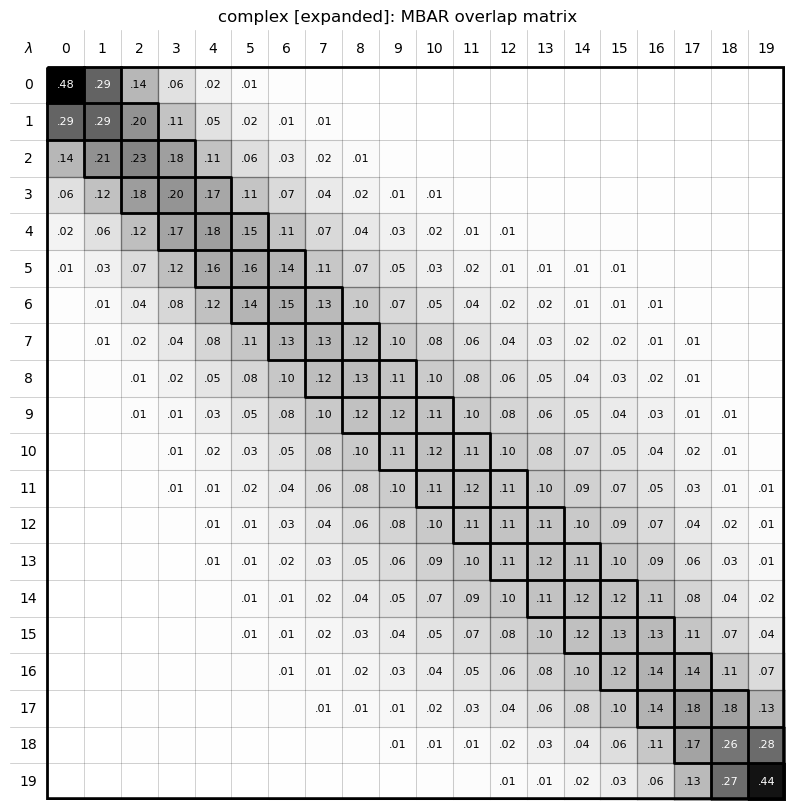

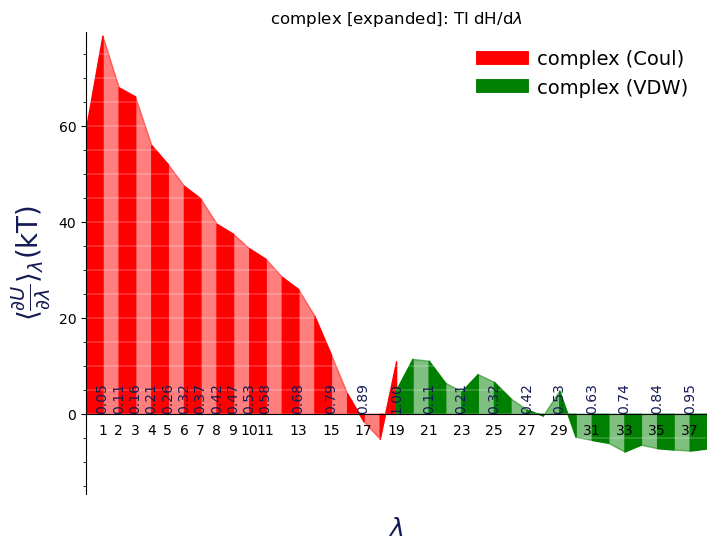

  solvent [expanded]: prod.xvg


2026-07-15 23:15:47.164 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:609 - Running equilibration detection.
2026-07-15 23:16:11.231 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:611 - Start index: 186.
2026-07-15 23:16:11.231 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:612 - Statistical inefficiency: 23.73.
2026-07-15 23:16:11.237 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:618 - Number of uncorrelated samples: 2390.
2026-07-15 23:16:11.257 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:609 - Running equilibration detection.
2026-07-15 23:16:24.526 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:611 - Start index: 0.
2026-07-15 23:16:24.527 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:612 - Statistical inefficiency: 1.01.
2026-07-15 23:16:24.666 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detec

  solvent [expanded]: 2390 dhdl / 56469 u_nk samples retained (post-burn-in, post-subsampling)
  [solvent | expanded] TI: 22.30 ± 0.19 kcal/mol
  [solvent | expanded] MBAR: 22.12 ± 0.03 kcal/mol


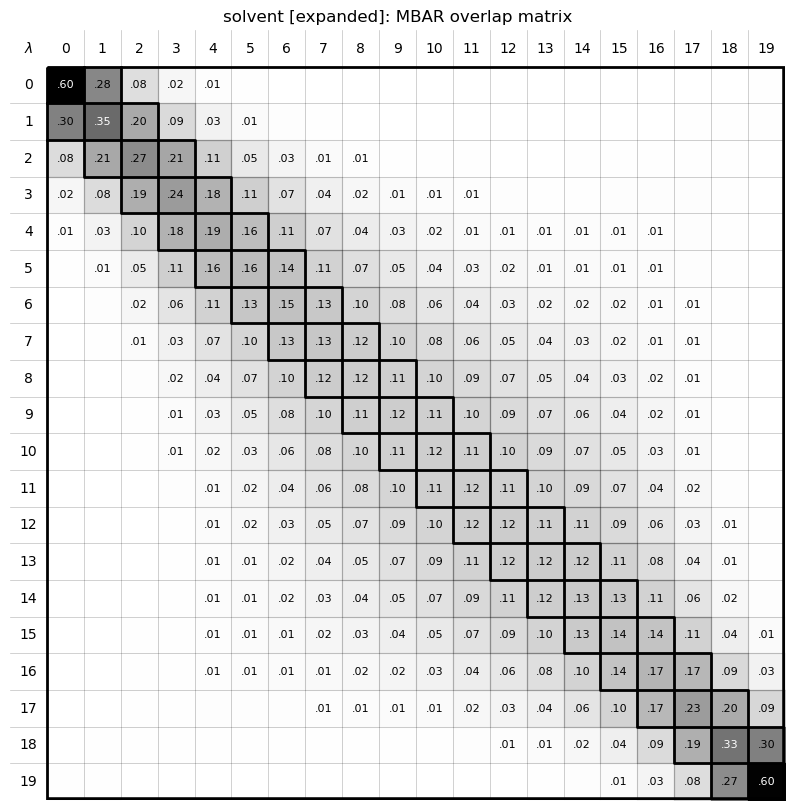

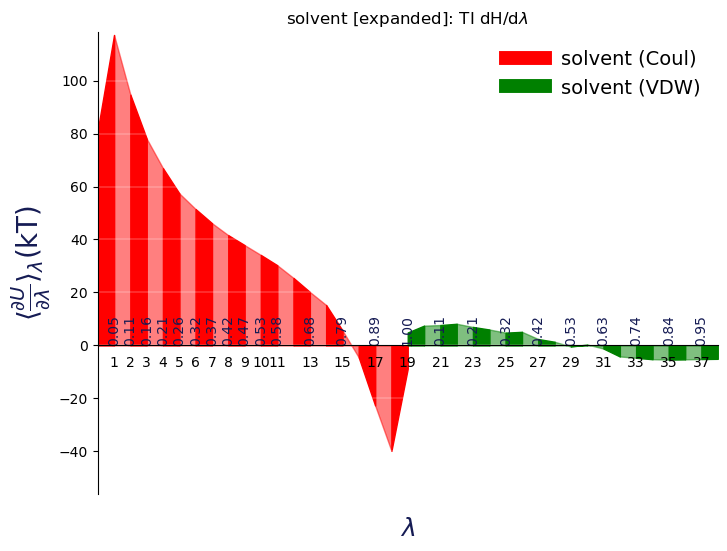

2026-07-15 23:16:26.383 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:609 - Running equilibration detection.



 Mode: fixed
  complex [fixed]: 20 state xvg files


2026-07-15 23:16:34.829 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:611 - Start index: 3725.
2026-07-15 23:16:34.830 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:612 - Statistical inefficiency: 17.63.
2026-07-15 23:16:34.833 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:618 - Number of uncorrelated samples: 971.
2026-07-15 23:16:34.843 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:609 - Running equilibration detection.
2026-07-15 23:16:43.966 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:611 - Start index: 5736.
2026-07-15 23:16:43.966 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:612 - Statistical inefficiency: 10.63.
2026-07-15 23:16:43.970 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:618 - Number of uncorrelated samples: 1421.
2026-07-15 23:16:44.045 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibr

  complex [fixed]: 35805 dhdl / 38086 u_nk samples retained (post-burn-in, post-subsampling)
  [complex | fixed] TI: 21.19 ± 0.24 kcal/mol
  [complex | fixed] MBAR: 21.14 ± 0.04 kcal/mol


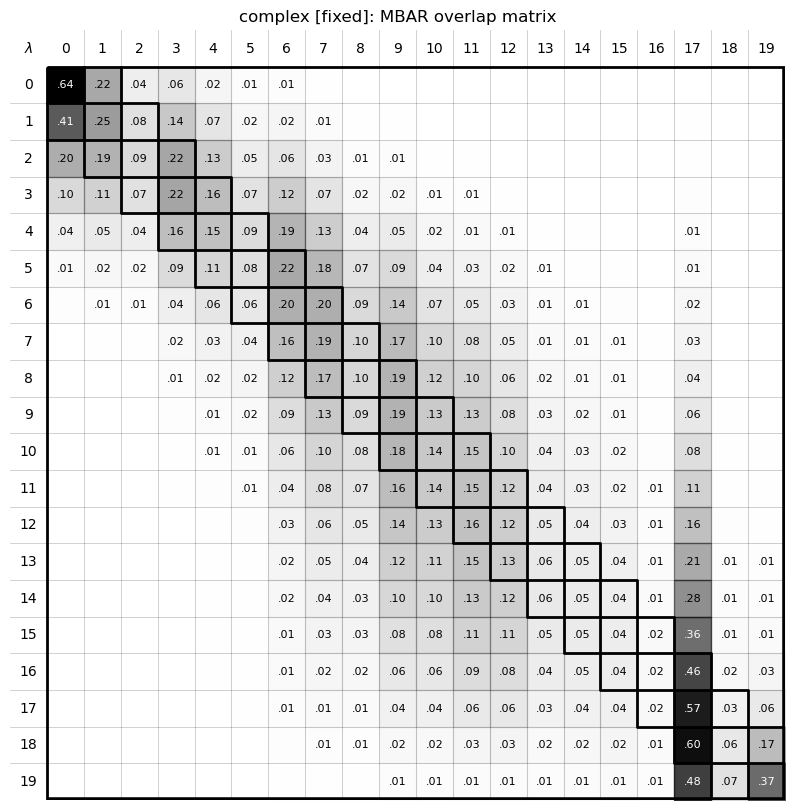

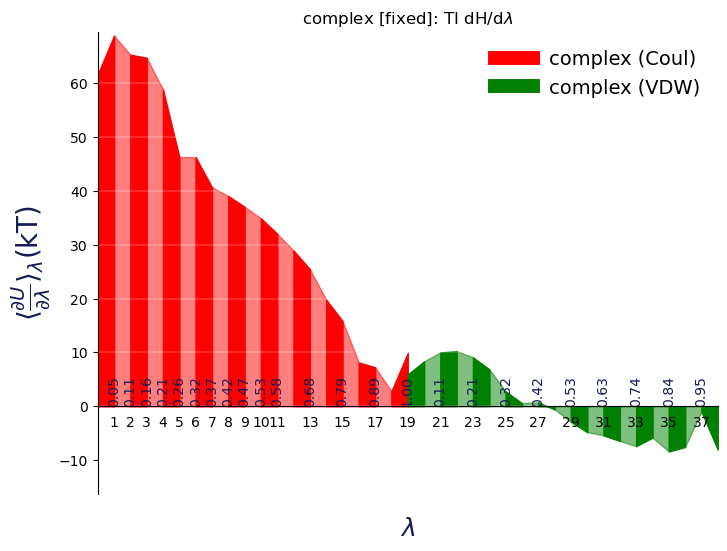

  solvent [fixed]: 20 state xvg files


2026-07-15 23:19:20.954 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:609 - Running equilibration detection.
2026-07-15 23:19:52.177 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:611 - Start index: 236.
2026-07-15 23:19:52.178 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:612 - Statistical inefficiency: 3.13.
2026-07-15 23:19:52.241 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:618 - Number of uncorrelated samples: 25135.
2026-07-15 23:19:52.268 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:609 - Running equilibration detection.
2026-07-15 23:20:24.720 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:611 - Start index: 246.
2026-07-15 23:20:24.720 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_detection:612 - Statistical inefficiency: 2.30.
2026-07-15 23:20:24.807 | DEBUG    | alchemlyb.preprocessing.subsampling:equilibrium_det

  solvent [fixed]: 824558 dhdl / 866928 u_nk samples retained (post-burn-in, post-subsampling)
  [solvent | fixed] TI: 22.08 ± 0.01 kcal/mol
  [solvent | fixed] MBAR: 22.06 ± 0.01 kcal/mol


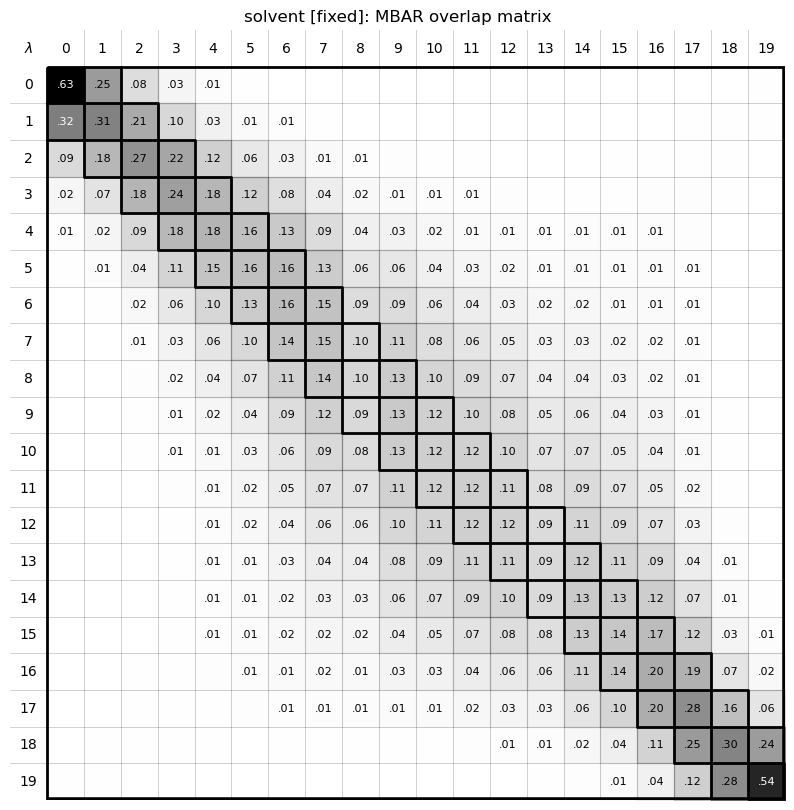

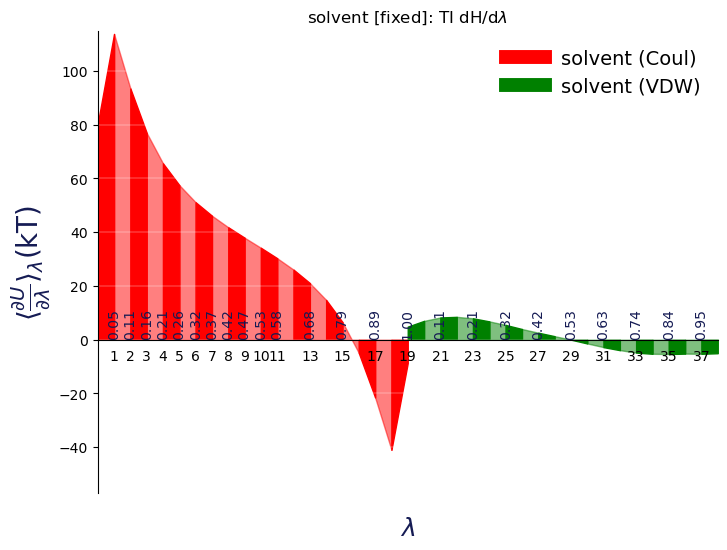

$\Delta\Delta G_{\text{bind}}$ summary

expanded:
  TI: ΔΔG = -0.94 ± 0.42 kcal/mol
  MBAR: ΔΔG = -1.03 ± 0.06 kcal/mol

fixed:
  TI: ΔΔG = -0.90 ± 0.24 kcal/mol
  MBAR: ΔΔG = -0.92 ± 0.04 kcal/mol
Method comparison (expanded vs fixed)
  TI: expanded -0.94 ± 0.42  |  fixed -0.90 ± 0.24  |  Δ = -0.05 kcal/mol
  MBAR: expanded -1.03 ± 0.06  |  fixed -0.92 ± 0.04  |  Δ = -0.11 kcal/mol


In [19]:
TEMPERATURE = 300.0  # Kelvin
MODE = "both"      # <-- "expanded", "fixed", or "both" (run both modes and compare)

def load_leg(leg_dir: Path, mode: str, temperature: float = TEMPERATURE):
    """Parse one production method's output for a leg into combined alchemlyb
    dHdl/u_nk formats and discard the burn-in/calibration period.

    For fixed-lambda, decorrelation is done PER STATE (each state's own
    timeseries) before concatenating -- decorrelating the concatenated
    multi-state object collapses the per-state structure and produces
    garbage estimates.
    """
    if mode == "expanded":
        xvg = leg_dir / "prod.xvg"
        if not xvg.exists():
            raise FileNotFoundError(
                f"mode='expanded' but no {xvg} found -- has the expanded-ensemble "
                f"production run finished?"
            )
        print(f"  {leg_dir.name} [expanded]: prod.xvg")
        dHdl = extract_dHdl(str(xvg), T=temperature)
        u_nk = extract_u_nk(str(xvg), T=temperature)
        # single timeseries -> decorrelate the whole thing
        dHdl = decorrelate_dhdl(dHdl, remove_burnin=True)
        u_nk = decorrelate_u_nk(u_nk, remove_burnin=True)

    elif mode == "fixed":
        xvgs = sorted(
            leg_dir.glob("lambda_*/prod.xvg"),
            key=lambda p: int(p.parent.name.split("_")[1]),
        )
        if not xvgs:
            raise FileNotFoundError(
                f"mode='fixed' but no {leg_dir}/lambda_*/prod.xvg files found."
            )
        print(f"  {leg_dir.name} [fixed]: {len(xvgs)} state xvg files")

        # Decorrelate EACH state's own timeseries, THEN concatenate.
        dHdl_list, u_nk_list = [], []
        for p in xvgs:
            d = extract_dHdl(str(p), T=temperature)
            u = extract_u_nk(str(p), T=temperature)
            dHdl_list.append(decorrelate_dhdl(d, remove_burnin=True))
            u_nk_list.append(decorrelate_u_nk(u, remove_burnin=True))
        dHdl = alchemlyb.concat(dHdl_list)
        u_nk = alchemlyb.concat(u_nk_list)

    else:
        raise ValueError(f"mode must be 'expanded' or 'fixed', got {mode!r}")

    print(f"  {leg_dir.name} [{mode}]: {len(dHdl)} dhdl / {u_nk.shape[0]} u_nk "
          f"samples retained (post-burn-in, post-subsampling)")
    return dHdl, u_nk


def estimate_leg(leg_dir: Path, label: str, mode: str, temperature: float = TEMPERATURE):
    """Estimate one leg's free energy via TI and MBAR for a single method,
    and produce the diagnostic plots (MBAR overlap matrix, TI dH/d$\lambda$ curve).

    Returns:
        results: dict of {estimator_name: (dG_kcal, err_kcal)}
        (ti, mbar): fitted estimator objects
    """
    dHdl, u_nk = load_leg(leg_dir, mode=mode, temperature=temperature)

    ti = TI().fit(dHdl)
    mbar = MBAR().fit(u_nk)

    results = {}
    for name, est in [("TI", ti), ("MBAR", mbar)]:
        dG = to_kcalmol(est.delta_f_, T=temperature).iloc[0, -1]
        err = to_kcalmol(est.d_delta_f_, T=temperature).iloc[0, -1]
        results[name] = (dG, err)
        print(f"  [{label} | {mode}] {name}: {dG:.2f} ± {err:.2f} kcal/mol")

    ax = plot_mbar_overlap_matrix(mbar.overlap_matrix)
    ax.set_title(f"{label} [{mode}]: MBAR overlap matrix")
    plt.savefig(leg_dir / f"overlap_matrix_{mode}.png", dpi=150, bbox_inches="tight")
    plt.show()

    ax = plot_ti_dhdl([ti], labels=[f"{label} (Coul)", f"{label} (VDW)"])
    ax.set_title(f"{label} [{mode}]: TI dH/d$\lambda$")
    plt.savefig(leg_dir / f"ti_dhdl_{mode}.png", dpi=150, bbox_inches="tight")
    plt.show()

    return results, (ti, mbar)


def compute_ddg(mode: str, temperature: float = TEMPERATURE):
    """Run both legs for one method and combine into $\Delta\Delta G_{\text{bind}}$."""
    print(f"\n Mode: {mode}")
    complex_results, _ = estimate_leg(complex_leg, "complex", mode=mode, temperature=temperature)
    solvent_results, _ = estimate_leg(solvent_leg, "solvent", mode=mode, temperature=temperature)

    ddg = {}
    for estimator in ("TI", "MBAR"):
        dG_solv, err_solv = solvent_results[estimator]
        dG_comp, err_comp = complex_results[estimator]
        ddG = dG_comp - dG_solv
        ddG_err = np.sqrt(err_solv**2 + err_comp**2)
        ddg[estimator] = (ddG, ddG_err)
    return ddg


modes = ["expanded", "fixed"] if MODE == "both" else [MODE]
all_ddg = {mode: compute_ddg(mode) for mode in modes}

#  summary 
print("$\\Delta\\Delta G_{\\text{bind}}$ summary")
for mode in modes:
    print(f"\n{mode}:")
    for estimator in ("TI", "MBAR"):
        ddG, ddG_err = all_ddg[mode][estimator]
        print(f"  {estimator}: ΔΔG = {ddG:.2f} ± {ddG_err:.2f} kcal/mol")

# if both, show the direct comparison
if MODE == "both":
    print("Method comparison (expanded vs fixed)")
    print("=" * 50)
    for estimator in ("TI", "MBAR"):
        exp_ddG, exp_err = all_ddg["expanded"][estimator]
        fix_ddG, fix_err = all_ddg["fixed"][estimator]
        diff = exp_ddG - fix_ddG
        print(f"  {estimator}: expanded {exp_ddG:.2f} ± {exp_err:.2f}  |  "
              f"fixed {fix_ddG:.2f} ± {fix_err:.2f}  |  Δ = {diff:.2f} kcal/mol")